In [1]:
# -*- coding: utf-8 -*-
"""
Created on 2023-01-01
Revised on 2026-04-03

@author:       Oscar Trevizo
@institution:  Harvard Extension School — Graduate Data Science Program (2023)
@context:      Independent project — toolbox vignette, R to Python (_r2p)
@environment:  Python 3.14.3 | myenv | MacBook Air M5

Prediction Accuracy: Regression — Toolbox Vignette (_r2p)
==========================================================

Purpose:
    A self-contained reference notebook for regression accuracy metrics.
    Defines the RegressionAccuracy class — the canonical Python equivalent
    of the R prediction.accuracy() function from Harvard Statistical
    Learning class (2021).

    This is the TOOLBOX version — focused on the metrics themselves,
    with a thorough formula reference and a simulated linear regression
    demo where ground truth parameters are known.

    Terminology note (from original R script):
      - Prediction ACCURACY → refers to REGRESSION metrics  (this notebook)
      - Prediction METRICS  → refers to CLASSIFICATION metrics
                              (see prediction_metrics_classification_r2p.ipynb)

Metrics covered (ISLR nomenclature, page refs preserved from R):
    RSS        = sum((y - yp)^2)           Sum of Squares Estimated (SSE) (ISLR p.62)
    RSE        = sqrt(RSS / (N-2))         Residual Standard Error          (ISLR p.66)
    TSS        = sum((y - mean(y))^2)      Total Sum of Squares (SST)       (ISLR p.70)
    SSR        = sum((yp - mean(y))^2)     Sum of Squares Regression        (= TSS - RSS)
    R_squared  = (TSS - RSS) / TSS         R² Statistic                     (ISLR p.69)
    SE         = RSE / sqrt(sum((x-mean(x))^2))  Standard Error (simple LR only)
    RMSE       = sqrt(RSS / N)             Root Mean Squared Error (added in Python)
    MAE        = mean(|y - yp|)            Mean Absolute Error    (added in Python)

R equivalent: prediction_metrics_regression.Rmd
R libraries:  stats (lm)
Python libs:  numpy, pandas, matplotlib, seaborn, statsmodels, sklearn

Suffix _r2p: This notebook was converted from R to Python.

Notes on R original:
    - prediction.accuracy() used global variable x for SE calculation.
      Fixed here: x_predictor is an optional parameter with clear docs.
    - RSE uses N-2 degrees of freedom (correct for simple linear regression).
      For multiple regression, df = N - p - 1. Documented explicitly.

Revision History:
    2023-01-01  Original R development (Harvard Elements of Statistical Learning, 2021)
                - R script: prediction_metrics_regression.Rmd
                - Based on functions by Dr. Sivachenko and Dr. Farutin

    2026-04-03  Converted to Python / Jupyter Notebook (_r2p)
                - prediction.accuracy() R fn → RegressionAccuracy class
                - Fixed R bug: global x dependency in SE → optional parameter
                - stats::lm() → statsmodels.OLS (full summary output)
                - Added: RMSE, MAE, residual plots, metrics dashboard
                - ISLR page references preserved in all comments
"""

'\nCreated on 2023-01-01\nRevised on 2026-04-03\n\n@author:       Oscar Trevizo\n@institution:  Harvard Extension School — Graduate Data Science Program (2023)\n@context:      Independent project — toolbox vignette, R to Python (_r2p)\n@environment:  Python 3.14.3 | myenv | MacBook Air M5\n\nPrediction Accuracy: Regression — Toolbox Vignette (_r2p)\n==========================================================\n\nPurpose:\n    A self-contained reference notebook for regression accuracy metrics.\n    Defines the RegressionAccuracy class — the canonical Python equivalent\n    of the R prediction.accuracy() function from Harvard Statistical\n    Learning class (2021).\n\n    This is the TOOLBOX version — focused on the metrics themselves,\n    with a thorough formula reference and a simulated linear regression\n    demo where ground truth parameters are known.\n\n    Terminology note (from original R script):\n      - Prediction ACCURACY → refers to REGRESSION metrics  (this notebook)\n     

# Prediction Accuracy: Regression — Toolbox Vignette

## Purpose

A self-contained reference for **regression accuracy metrics**.
Defines the `RegressionAccuracy` class — the canonical Python equivalent
of the R `prediction.accuracy()` function from Harvard Statistical
Learning class (2021).

> **Terminology note** (from original R script):
> - *Prediction **accuracy*** → refers to **regression** metrics (this notebook)
> - *Prediction **metrics*** → refers to **classification** metrics
>   (see `prediction_metrics_classification_r2p.ipynb`)

**R equivalent:** `prediction_metrics_regression.Rmd`

**Suffix `_r2p`:** This notebook was converted from R to Python.

## Metrics Reference

Notation: `y` = truth, `yp` = predicted. ISLR page references preserved.

| Symbol | Name | Formula | ISLR |
|--------|------|---------|------|
| RSS | Residual Sum of Squares (SSE) | Σ(y − ŷ)² | p.62 |
| RSE | Residual Standard Error | √(RSS / (N−2)) | p.66 |
| TSS | Total Sum of Squares (SST) | Σ(y − ȳ)² | p.70 |
| SSR | Sum of Squares Regression | Σ(ŷ − ȳ)² = TSS − RSS | — |
| R² | R-squared | (TSS − RSS) / TSS = SSR / TSS | p.69 |
| SE | Standard Error of slope | RSE / √Σ(x − x̄)² | — |
| RMSE | Root Mean Squared Error | √(RSS / N) | — |
| MAE | Mean Absolute Error | mean(\|y − ŷ\|) | — |

### Key relationships

- RSS + SSR = TSS (variance decomposition)
- R² = 1 − RSS/TSS = SSR/TSS ∈ [0, 1]
- RSE uses N−2 df for simple LR; N−p−1 for multiple regression
- RMSE = √(RSS/N) — does not adjust for degrees of freedom
- RSE = √(RSS/(N−2)) — does adjust, making it comparable across sample sizes

## Imports

In [2]:
# Standard libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Linear regression — mirrors R: stats::lm()
import statsmodels.api as sm
import statsmodels.formula.api as smf

# sklearn metrics — for cross-validation
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error

# Display settings
pd.set_option('display.max_columns', 20)
sns.set_theme(style='whitegrid')

# -----------------------------------------------------------------------
# Harvard color palette — mirrors R setup chunk
# -----------------------------------------------------------------------
CRIMSON   = '#A51C30'
ROYALBLUE = '#002366'
SLATE     = '#8996A0'
IVY       = '#52854C'
SAFFRON   = '#D16103'
INDIGO    = '#293352'
SHADE     = '#BAC5C6'

print('Imports complete.')

Imports complete.


---

## The RegressionAccuracy Class

The canonical toolbox class for regression metrics.
Mirrors R `prediction.accuracy()` exactly, with two fixes and three additions.

### R → Python mapping

| R | Python |
|---|--------|
| `prediction.accuracy(truth, predicted)` | `RegressionAccuracy(truth, predicted)` |
| `lm.accuracy$RSS` | `acc.RSS` |
| `lm.accuracy$R_squared` | `acc.R_squared` |
| Named list return | Class attributes + `to_dict()` + `to_dataframe()` |

### Bug fix from original R
```r
SE <- RSE/sqrt(sum((x-mean(x))^2))  # BUG: uses global x
```
Fixed: `x_predictor` is now an explicit optional parameter.
If not provided, `SE` is set to `np.nan` with a clear note.

In [3]:
class RegressionAccuracy:
    """
    Regression prediction accuracy metrics.

    The canonical Python equivalent of R function prediction.accuracy()
    from Harvard Elements of Statistical Learning class (2021).
    Original R code by Dr. Sivachenko and Dr. Farutin;
    expanded by Oscar Trevizo.

    Terminology follows ISLR (James et al.):
      - Prediction ACCURACY → regression metrics (this class)
      - Prediction METRICS  → classification metrics (PredictionMetrics class)

    Parameters
    ----------
    truth : array-like of float
        Ground truth (observed) values. Mirrors R: y.
    predicted : array-like of float
        Predicted values. Mirrors R: yp.
    x_predictor : array-like of float, optional
        Single predictor variable — required only for SE calculation
        (simple linear regression). Mirrors R: global x.
        If not provided, SE = np.nan.
    df_residual : int, optional
        Residual degrees of freedom for RSE.
        Default: N-2 (simple LR). Use N-p-1 for multiple regression.

    Attributes
    ----------
    RSS       : float — Residual Sum of Squares (SSE)          ISLR p.62
    RSE       : float — Residual Standard Error                ISLR p.66
    TSS       : float — Total Sum of Squares (SST)             ISLR p.70
    SSR       : float — Sum of Squares Regression (TSS - RSS)
    R_squared : float — R² Statistic                           ISLR p.69
    SE        : float — Standard Error of slope (simple LR only)
    RMSE      : float — Root Mean Squared Error (= sqrt(RSS/N))
    MAE       : float — Mean Absolute Error
    N         : int   — number of observations

    Examples
    --------
    >>> import numpy as np
    >>> rng = np.random.default_rng(42)
    >>> x = np.linspace(-3, 3, 100)
    >>> y = 1 + 2*x + rng.normal(0, 1, 100)
    >>> yp = 1.01 + 1.96*x
    >>> acc = RegressionAccuracy(y, yp, x_predictor=x)
    >>> acc.print_accuracy()
    """

    def __init__(self, truth, predicted, x_predictor=None, df_residual=None):
        truth     = np.array(truth,     dtype=float)
        predicted = np.array(predicted, dtype=float)

        # Validate lengths — mirrors R: if (length(truth) != length(predicted)) stop(...)
        if len(truth) != len(predicted):
            raise ValueError('truth and predicted must be the same length!')

        # Remove NaN — mirrors R: bKeep = !is.na(truth) & !is.na(predicted)
        mask      = ~(np.isnan(truth) | np.isnan(predicted))
        y         = truth[mask]
        yp        = predicted[mask]
        self.N    = len(y)

        # Degrees of freedom for RSE
        # Default N-2 for simple LR — mirrors R: sqrt(RSS/(N-2))
        # Pass df_residual=N-p-1 for multiple regression
        df = df_residual if df_residual is not None else self.N - 2

        # Core metrics — mirrors R prediction.accuracy() body
        self.RSS       = float(np.sum((y - yp) ** 2))              # ISLR p.62
        self.RSE       = float(np.sqrt(self.RSS / df))             # ISLR p.66
        self.TSS       = float(np.sum((y - np.mean(y)) ** 2))      # ISLR p.70
        self.SSR       = float(np.sum((yp - np.mean(y)) ** 2))     # TSS - RSS
        self.R_squared = float((self.TSS - self.RSS) / self.TSS
                               if self.TSS > 0 else np.nan)        # ISLR p.69

        # SE — mirrors R: RSE/sqrt(sum((x-mean(x))^2))
        # Fixed: x_predictor is explicit parameter, not global variable
        if x_predictor is not None:
            x_arr    = np.array(x_predictor, dtype=float)[mask]
            denom    = np.sum((x_arr - np.mean(x_arr)) ** 2)
            self.SE  = float(self.RSE / np.sqrt(denom)) if denom > 0 else np.nan
        else:
            self.SE  = np.nan   # SE requires x_predictor (simple LR only)

        # Additional metrics — not in R original, added for completeness
        self.RMSE = float(np.sqrt(self.RSS / self.N))              # no df adjustment
        self.MAE  = float(np.mean(np.abs(y - yp)))

    def print_accuracy(self):
        """
        Print all metrics to stdout.
        Mirrors R: cat() output from prediction.accuracy() call.
        ISLR page references preserved.
        """
        print(f' N         = {self.N:6d}   ..................Number of observations')
        print(f' RSS       = {self.RSS:12.6f} ......Sum of Squares Estimated (SSE) (ISLR p.62)')
        print(f' RSE       = {self.RSE:12.6f} ......Residual Standard Error (ISLR p.66)')
        print(f' TSS       = {self.TSS:12.6f} ......Total Sum of Squares (SST) (ISLR p.70)')
        print(f' SSR       = {self.SSR:12.6f} ......Sum of Squares Regression (TSS - RSS)')
        print(f' R_squared = {self.R_squared:12.6f} ......R² Statistic (TSS-RSS)/TSS (ISLR p.69)')
        print(f' SE        = {self.SE!s:>12} ......Standard Error of slope (simple LR)')
        print(f' RMSE      = {self.RMSE:12.6f} ......Root Mean Squared Error (= sqrt(RSS/N))')
        print(f' MAE       = {self.MAE:12.6f} ......Mean Absolute Error')

    def to_dict(self):
        """Return all metrics as a dictionary."""
        return dict(N=self.N, RSS=self.RSS, RSE=self.RSE, TSS=self.TSS,
                    SSR=self.SSR, R_squared=self.R_squared, SE=self.SE,
                    RMSE=self.RMSE, MAE=self.MAE)

    def to_dataframe(self):
        """Return metrics as a single-row DataFrame for model comparison."""
        return pd.DataFrame([self.to_dict()])

    def __repr__(self):
        return (f'RegressionAccuracy(N={self.N}, RSS={self.RSS:.4f}, '
                f'RSE={self.RSE:.4f}, R²={self.R_squared:.4f}, '
                f'RMSE={self.RMSE:.4f})')


print('RegressionAccuracy class defined.')
print()

# Quick smoke test with known values
_y  = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
_yp = np.array([1.1, 1.9, 3.2, 3.8, 5.1])
_acc = RegressionAccuracy(_y, _yp)
print('Smoke test:')
_acc.print_accuracy()

RegressionAccuracy class defined.

Smoke test:
 N         =      5   ..................Number of observations
 RSS       =     0.110000 ......Sum of Squares Estimated (SSE) (ISLR p.62)
 RSE       =     0.191485 ......Residual Standard Error (ISLR p.66)
 TSS       =    10.000000 ......Total Sum of Squares (SST) (ISLR p.70)
 SSR       =     9.910000 ......Sum of Squares Regression (TSS - RSS)
 R_squared =     0.989000 ......R² Statistic (TSS-RSS)/TSS (ISLR p.69)
 SE        =          nan ......Standard Error of slope (simple LR)
 RMSE      =     0.148324 ......Root Mean Squared Error (= sqrt(RSS/N))
 MAE       =     0.140000 ......Mean Absolute Error


---

## Simulate the Data

Mirrors R:
```r
N=100; sd_delta=1; slope=2; intersection=1
x <- seq(-3, 3, length=N)
y <- intersection + slope*x + rnorm(100, sd=sd_delta)
```

We simulate data where we **know the true parameters** — intercept=1, slope=2.
The fitted model should recover values close to these, and the metrics
should reflect the known noise level `sd_delta=1`.

In [4]:
# Simulate — mirrors R: set parameters and generate data
# R did not set.seed() for this — we use a fixed seed for reproducibility
rng = np.random.default_rng(seed=42)

N            = 100
sd_delta     = 1
slope        = 2
intersection = 1

# X: uniform sequence — mirrors R: seq(-3, 3, length=N)
x = np.linspace(-3, 3, N)

# Y: known linear relationship + noise — mirrors R: intersection + slope*x + rnorm(100, sd=sd_delta)
y = intersection + slope * x + rng.normal(0, sd_delta, N)

print(f'Simulation parameters:')
print(f'  N            = {N}')
print(f'  intercept    = {intersection}   (true value)')
print(f'  slope        = {slope}   (true value)')
print(f'  sd_delta     = {sd_delta}   (noise level)')
print(f'  x range      : [{x.min():.1f}, {x.max():.1f}]')
print(f'  y range      : [{y.min():.3f}, {y.max():.3f}]')

Simulation parameters:
  N            = 100
  intercept    = 1   (true value)
  slope        = 2   (true value)
  sd_delta     = 1   (noise level)
  x range      : [-3.0, 3.0]
  y range      : [-6.466, 7.279]


## Linear Regression Model

Mirrors R: `m <- lm(y~x); summary(m)`

We expect the model to recover intercept ≈ 1 and slope ≈ 2.
R's comment in the original: *"intercept is 1.01, slope is 1.96"*.

In [5]:
# Fit OLS — mirrors R: lm(y~x)
df_sim = pd.DataFrame({'y': y, 'x': x})
m      = smf.ols('y ~ x', data=df_sim).fit()

# Full summary — mirrors R: summary(m)
print(m.summary())
print()
print(f'Recovered intercept : {m.params["Intercept"]:.4f}  (true = {intersection})')
print(f'Recovered slope     : {m.params["x"]:.4f}  (true = {slope})')

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.951
Method:                 Least Squares   F-statistic:                     1919.
Date:                Fri, 03 Apr 2026   Prob (F-statistic):           3.59e-66
Time:                        14:56:34   Log-Likelihood:                -114.85
No. Observations:                 100   AIC:                             233.7
Df Residuals:                      98   BIC:                             238.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.9497      0.077     12.322      0.0

## Predict

Mirrors R: `yp <- predict(m)`

R predicts on the training set when no `newdata` is supplied.
We do the same.

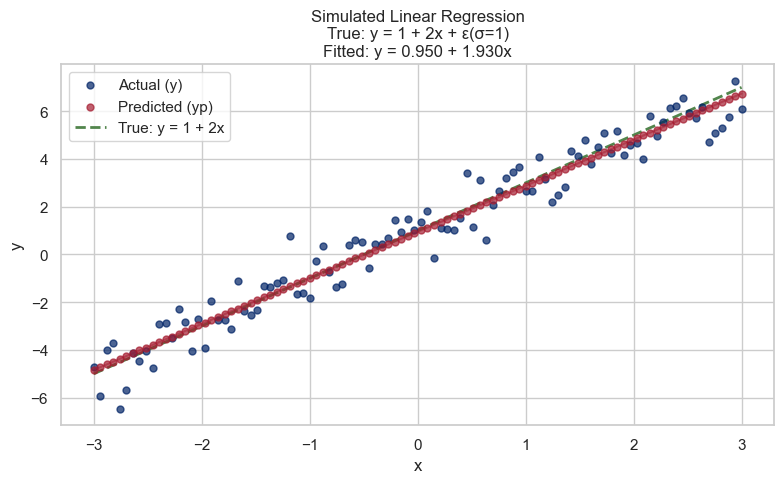

In [6]:
# Predict on training data — mirrors R: yp <- predict(m)
yp = m.predict(df_sim)

# Plot actuals and predictions — mirrors R: plot(x,y); points(x,yp,col='red')
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y,  color=ROYALBLUE, s=25, alpha=0.7,
           label='Actual (y)',     zorder=3)         # mirrors R: pch=19
ax.scatter(x, yp, color=CRIMSON,   s=25, alpha=0.7,
           label='Predicted (yp)', zorder=3)         # mirrors R: col='red'
ax.plot(x, yp, color=CRIMSON, linewidth=1.5, alpha=0.5)

# True line for reference
ax.plot(x, intersection + slope * x, color=IVY, linewidth=2,
        linestyle='--', label=f'True: y = {intersection} + {slope}x', zorder=2)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Simulated Linear Regression\n'
             f'True: y = {intersection} + {slope}x + ε(σ={sd_delta})\n'
             f'Fitted: y = {m.params["Intercept"]:.3f} + {m.params["x"]:.3f}x')
ax.legend()
plt.tight_layout()
plt.show()

## Get Accuracy Metrics

Mirrors R:
```r
lm.accuracy <- prediction.accuracy(y, yp)
RSS <- lm.accuracy$RSS
RSE <- lm.accuracy$RSE
...
cat(' RSS = ', RSS, '..............Sum of Squares Estimated...')
```

In [7]:
# Compute accuracy — mirrors R: prediction.accuracy(y, yp)
lm_accuracy = RegressionAccuracy(y, yp.values, x_predictor=x)

print('Regression Accuracy Metrics')
print('(mirrors R: cat() output from prediction.accuracy(y, yp))')
print()
lm_accuracy.print_accuracy()

Regression Accuracy Metrics
(mirrors R: cat() output from prediction.accuracy(y, yp))

 N         =    100   ..................Number of observations
 RSS       =    58.223192 ......Sum of Squares Estimated (SSE) (ISLR p.62)
 RSE       =     0.770788 ......Residual Standard Error (ISLR p.66)
 TSS       =  1198.361209 ......Total Sum of Squares (SST) (ISLR p.70)
 SSR       =  1140.138017 ......Sum of Squares Regression (TSS - RSS)
 R_squared =     0.951414 ......R² Statistic (TSS-RSS)/TSS (ISLR p.69)
 SE        = 0.04405865656957096 ......Standard Error of slope (simple LR)
 RMSE      =     0.763041 ......Root Mean Squared Error (= sqrt(RSS/N))
 MAE       =     0.631863 ......Mean Absolute Error


In [8]:
# Pull individual values — mirrors R: RSS <- lm.accuracy$RSS etc.
RSS       = lm_accuracy.RSS
RSE       = lm_accuracy.RSE
TSS       = lm_accuracy.TSS
SSR       = lm_accuracy.SSR
R_squared = lm_accuracy.R_squared
SE        = lm_accuracy.SE
RMSE      = lm_accuracy.RMSE
MAE       = lm_accuracy.MAE

print(f'Individual values (mirrors R: lm.accuracy$RSS notation):')
print(f'  RSS       = {RSS:.6f}')
print(f'  RSE       = {RSE:.6f}')
print(f'  TSS       = {TSS:.6f}')
print(f'  SSR       = {SSR:.6f}')
print(f'  R_squared = {R_squared:.6f}')
print(f'  SE        = {SE:.6f}')
print(f'  RMSE      = {RMSE:.6f}')
print(f'  MAE       = {MAE:.6f}')
print()
print(f'Verification: RSS + SSR = {RSS + SSR:.4f}  TSS = {TSS:.4f}  '
      f'(should be equal ✓)' if abs((RSS + SSR) - TSS) < 1e-6 else '(mismatch — check)')

Individual values (mirrors R: lm.accuracy$RSS notation):
  RSS       = 58.223192
  RSE       = 0.770788
  TSS       = 1198.361209
  SSR       = 1140.138017
  R_squared = 0.951414
  SE        = 0.044059
  RMSE      = 0.763041
  MAE       = 0.631863

Verification: RSS + SSR = 1198.3612  TSS = 1198.3612  (should be equal ✓)


## Diagnostic Plots

Standard OLS diagnostics — mirrors the spirit of R's `plot(m)` four-panel output.
Uses the `plot_diagnostics()` helper from `multiple_linear_regression_ISLR_Ch3_OJ.ipynb`
— reproduced here as a self-contained toolbox.

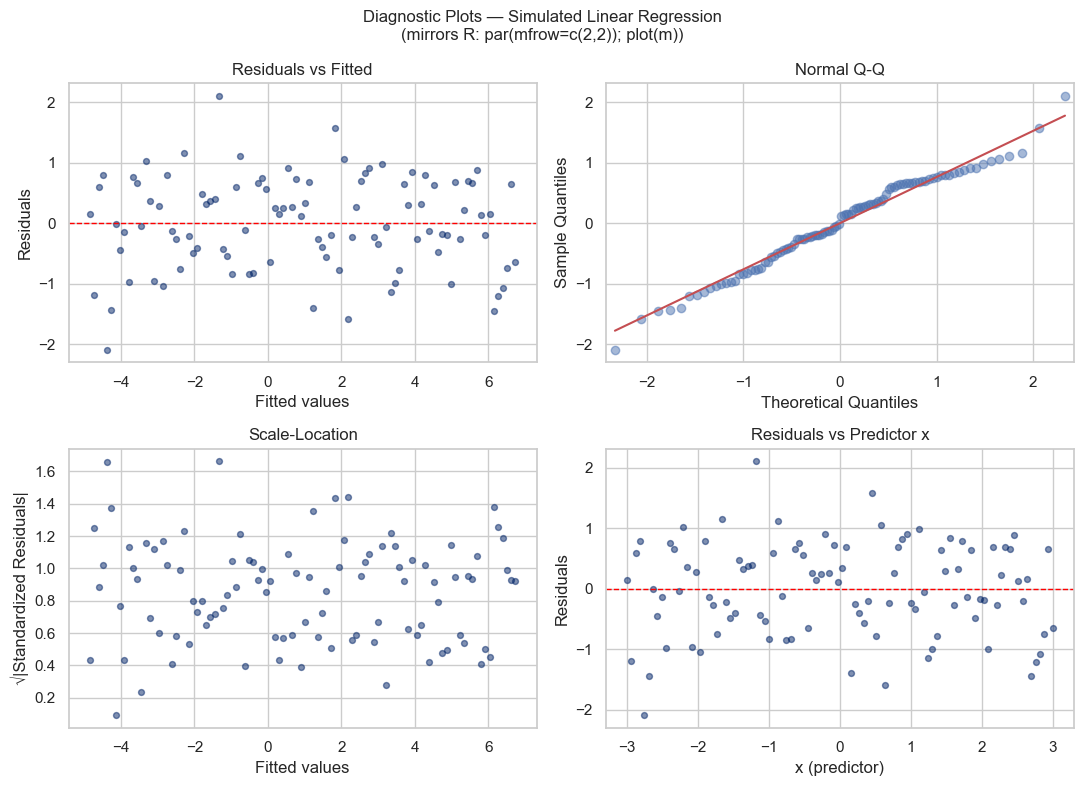

In [9]:
# Residuals — mirrors R: plot(m) four-panel diagnostic
residuals  = y - yp.values
fitted     = yp.values
std_resid  = residuals / residuals.std()

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# Panel 1: Residuals vs Fitted
axes[0, 0].scatter(fitted, residuals, alpha=0.5, s=18, color=ROYALBLUE)
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0, 0].set_xlabel('Fitted values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted')

# Panel 2: Q-Q plot
sm.qqplot(residuals, line='s', ax=axes[0, 1], alpha=0.5)
axes[0, 1].set_title('Normal Q-Q')

# Panel 3: Scale-Location
axes[1, 0].scatter(fitted, np.sqrt(np.abs(std_resid)),
                   alpha=0.5, s=18, color=ROYALBLUE)
axes[1, 0].set_xlabel('Fitted values')
axes[1, 0].set_ylabel('√|Standardized Residuals|')
axes[1, 0].set_title('Scale-Location')

# Panel 4: Residuals vs X
axes[1, 1].scatter(x, residuals, alpha=0.5, s=18, color=ROYALBLUE)
axes[1, 1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1, 1].set_xlabel('x (predictor)')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('Residuals vs Predictor x')

fig.suptitle('Diagnostic Plots — Simulated Linear Regression\n'
             f'(mirrors R: par(mfrow=c(2,2)); plot(m))', fontsize=12)
plt.tight_layout()
plt.show()

## Metrics Dashboard

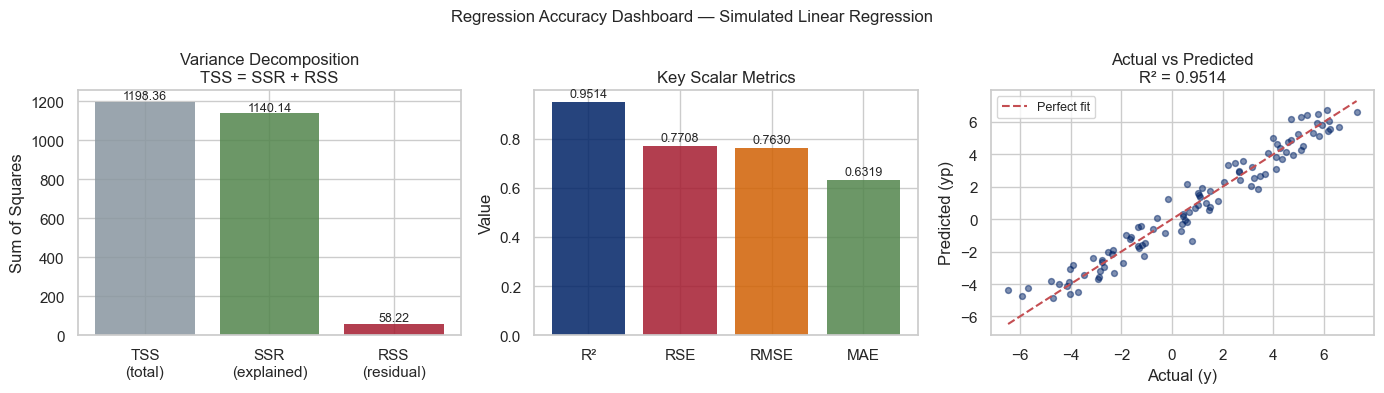

In [10]:
# Visual metrics dashboard
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: Variance decomposition (RSS, SSR, TSS)
labels = ['TSS\n(total)', 'SSR\n(explained)', 'RSS\n(residual)']
values = [TSS, SSR, RSS]
colors = [SLATE, IVY, CRIMSON]
bars   = axes[0].bar(labels, values, color=colors, alpha=0.85, edgecolor='none')
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + TSS*0.01,
                 f'{val:.2f}', ha='center', fontsize=9)
axes[0].set_title('Variance Decomposition\nTSS = SSR + RSS')
axes[0].set_ylabel('Sum of Squares')

# Panel 2: Key scalar metrics
metric_names  = ['R²', 'RSE', 'RMSE', 'MAE']
metric_values = [R_squared, RSE, RMSE, MAE]
bar_colors    = [ROYALBLUE, CRIMSON, SAFFRON, IVY]
bars2 = axes[1].bar(metric_names, metric_values,
                     color=bar_colors, alpha=0.85, edgecolor='none')
for bar, val in zip(bars2, metric_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                 f'{val:.4f}', ha='center', fontsize=9)
axes[1].set_title('Key Scalar Metrics')
axes[1].set_ylabel('Value')

# Panel 3: Actual vs Predicted
axes[2].scatter(y, yp.values, alpha=0.5, s=18, color=ROYALBLUE)
min_val = min(y.min(), yp.values.min())
max_val = max(y.max(), yp.values.max())
axes[2].plot([min_val, max_val], [min_val, max_val],
             'r--', linewidth=1.5, label='Perfect fit')
axes[2].set_xlabel('Actual (y)')
axes[2].set_ylabel('Predicted (yp)')
axes[2].set_title(f'Actual vs Predicted\nR² = {R_squared:.4f}')
axes[2].legend(fontsize=9)

plt.suptitle('Regression Accuracy Dashboard — Simulated Linear Regression',
             fontsize=12)
plt.tight_layout()
plt.show()

---

## Metrics DataFrame — Easy Export

Same pattern as `PredictionMetrics.to_dataframe()` — useful for
multi-model comparison tables.

In [11]:
metrics_df = lm_accuracy.to_dataframe()
metrics_df.insert(0, 'Model', 'OLS (simulated, N=100)')
print('Metrics as DataFrame (to_dataframe() method):')
print(metrics_df.to_string(index=False, float_format='{:.6f}'.format))

Metrics as DataFrame (to_dataframe() method):
                 Model   N       RSS      RSE         TSS         SSR  R_squared       SE     RMSE      MAE
OLS (simulated, N=100) 100 58.223192 0.770788 1198.361209 1140.138017   0.951414 0.044059 0.763041 0.631863


---

# Summary and Conclusions

## Key Takeaways

1. **RegressionAccuracy is the canonical toolbox class** for regression metrics,
   mirroring R's `prediction.accuracy()` with two fixes and two additions.

2. **Known-parameter simulation:** Using `slope=2`, `intercept=1`, `sd_delta=1`
   on a uniform X grid makes it easy to verify that the model recovers the
   true parameters and that metrics are in the expected range.

3. **RSE vs. RMSE:** RSE adjusts for degrees of freedom (`N-2` for simple LR)
   while RMSE uses `N`. For large N the difference is negligible; for small N
   it matters. This notebook computes both explicitly.

4. **SE bug fix:** The original R function used the global variable `x` inside
   `prediction.accuracy()` for SE. Fixed here with an explicit `x_predictor`
   parameter — proper Python practice.

5. **Variance decomposition:** TSS = SSR + RSS — the bar chart makes this
   identity visual. R² = SSR/TSS = fraction of variance explained.

## R → Python Mapping

| R | Python |
|---|--------|
| `prediction.accuracy(truth, predicted)` | `RegressionAccuracy(truth, predicted, x_predictor=x)` |
| `lm.accuracy$RSS` | `acc.RSS` |
| `lm.accuracy$RSE` | `acc.RSE` |
| `lm.accuracy$R_squared` | `acc.R_squared` |
| `lm.accuracy$SE` | `acc.SE` |
| Named list return | Class attributes + `to_dict()` + `to_dataframe()` |
| `stats::lm(y~x)` | `statsmodels.formula.api.ols('y~x', data)` |
| `summary(m)` | `m.summary()` |
| `predict(m)` | `m.predict(df)` |
| `seq(-3, 3, length=N)` | `np.linspace(-3, 3, N)` |
| `rnorm(N, sd=sd_delta)` | `rng.normal(0, sd_delta, N)` |
| `par(mfrow=c(2,2)); plot(m)` | Four-panel matplotlib diagnostic |

## References

1. Harvard Elements of Statistical Learning (2021), Dr. Andrey Sivachenko
   and Dr. Victor A. Farutin. Original R `prediction.accuracy()` function.
2. Gareth James, et al. *An Introduction to Statistical Learning with
   Applications in R*. Springer. ISBN 978-1-4614-7137-0.
   - p.62: RSS definition
   - p.66: RSE definition
   - p.69: R² definition
   - p.70: TSS definition
3. James, G., Witten, D., Hastie, T., Tibshirani, R., Taylor, J.
   *An Introduction to Statistical Learning with Applications in Python*.
   Springer, 2023. https://www.statlearning.com